# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Analisis inicial de los datos**: 

    - No se observan valores nulos en todo el dataset
    - La columna date es de tipo object y debería de ser tipo fecha. Por lo que se tiene que hacer un cambio en el tipo de dato en esta columna


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
# TODO: calcula cuántos user_id duplicados existen
duplicados_user = df.duplicated(subset=['user_id']).sum()

# TODO: imprime el resultado
print("Duplicados en user_id:", duplicados_user)

Duplicados en user_id: 0


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Convierte date a datetime
df["date"] = pd.to_datetime(df['date'], errors = 'coerce')

In [7]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico de la columna Gasto
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de la columna Gasto con los usuarios donde su gasto es mayor a cero
df[df['gasto'] > 0]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

In [11]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [12]:
# Explorar variables categóricas y cómo se distribuyen
categorical_cols = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type', 'converted']

for col in categorical_cols:
    print(f"\n📌 Distribución de {col}:")
    print(df[col].value_counts())
    print("\nProporciones:")
    print(df[col].value_counts(normalize=True).round(3))


📌 Distribución de landing:
B    20018
A    19982
Name: landing, dtype: int64

Proporciones:
B    0.5
A    0.5
Name: landing, dtype: float64

📌 Distribución de region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Proporciones:
Norte        0.279
Centro       0.240
Sur          0.201
Occidente    0.160
Oriente      0.120
Name: region, dtype: float64

📌 Distribución de dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Proporciones:
Mobile     0.621
Desktop    0.379
Name: dispositivo, dtype: float64

📌 Distribución de traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Proporciones:
Organic     0.450
Ads         0.298
Email       0.153
Referral    0.099
Name: traffic_source, dtype: float64

📌 Distribución de user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

Proporciones:
Nuevo    

✍️ **REVISIÓN DE CALIDAD DE DATOS**: 

    - Todas las columnas tienen valores esperados. 
    - No existen usarios repetidos en todo el dataset
    - La fecha esta en formato Date y nos muestra que sólo se estan evaluando registros hechos durante el mes de enero del 2026
    - En la columna Gastos se tienen datos coherentes. Ya que la información estadistica para usarios con gasto diferente de 0 es igual a la información estadistica de los usuarios que si se convirtieron.
    - Las columnas con variables categóricas tambien se ve que los datos obtenidos son los esperados ya que si se suman las cantidades de usuarios que entran en cada una de sus categorias se llega a la suma total de registros que se tienen en el dataset.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [13]:
#Se genera una copia del data set origianl para poder trabajar sobre este
data=df.copy()
data.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [14]:
# Gasto por versión
gasto_A = data[(data['converted']==1) & (data['landing']=='A')] ['gasto']
gasto_B = data[(data['converted']==1) & (data['landing']=='B')] ['gasto']

# Verificar cantidad de datos que tiene cada grupo
print("\nCantidad de datos:")
print(f"A: {len(gasto_A)}, B: {len(gasto_B)}")


Cantidad de datos:
A: 2512, B: 3194


<div class="alert alert-block alert-success">
<b>Filtro de Clientes y Gasto Promedio</b> <a class="tocSkip"></a>

Filtraste correctamente solo los usuarios convertidos (converted = 1).

</div>

In [15]:
print("Información estadística del gasto de usuarios convertidos expuestos a la página A")
print(gasto_A.describe())
print("")
print("Información estadística del gasto de usuarios convertidos expuestos a la página b")
print(gasto_B.describe())

Información estadística del gasto de usuarios convertidos expuestos a la página A
count    2512.000000
mean       61.086572
std        28.875470
min        12.120000
25%        40.612500
50%        55.840000
75%        74.837500
max       303.680000
Name: gasto, dtype: float64

Información estadística del gasto de usuarios convertidos expuestos a la página b
count    3194.00000
mean       68.74536
std        32.00102
min        12.98000
25%        45.21000
50%        62.57000
75%        84.27750
max       249.99000
Name: gasto, dtype: float64


### Prueba T-test

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio por usuario convertido que estuvieron expuestos a la versión A se comporta estadisticamente igual que los que estuvieron expuestos a la versión B
- **Hipótesis alternativa (H₁):** El gasto promedio por usuario convertido que estuvieron expuestos a la versión A se comporta estadisticamente diferente que los que estuvieron expuestos a la versión B

<div class="alert alert-block alert-success">
<b>Definicion de Hipotesis</b> <a class="tocSkip"></a>

Las hipotesis nula (H0) y alternativa (H1) estan correctamente formuladas y son coherentes con el objetivo del analisis. Una hipotesis bien planteada es la base de cualquier prueba estadistica rigurosa.

</div>

In [16]:
from scipy.stats import levene

# Prueba de varianzas iguales
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")
alpha = 0.05  # umbral de significancia

if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08
Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).


In [17]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [18]:
#Se evalua la prueba T a la hipotesis nula con un porcentage de certeza del 95%
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [19]:
# Calcular promedios de gasto entre las dos pruebas
media_A = gasto_A.mean()
media_B = gasto_B.mean()

print('El promedio de gasto de los usuarios convertidos en la página A es: ', media_A)
print('El promedio de gasto de los usuarios convertidos en la página B es: ', media_B)
print('La diferencia es de: ', media_A - media_B)

El promedio de gasto de los usuarios convertidos en la página A es:  61.0865724522293
El promedio de gasto de los usuarios convertidos en la página B es:  68.74536005009392
La diferencia es de:  -7.658787597864624


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula: Hay evidencia estadística de comportamiento diferente entre e gasto de los ususarios expuestos a la página A y a los expuestos a la página B.

**Interpretación de negocio:**  
Con base en una  prueba t de dos muestras independientes, encontramos evidencia estadística de una diferencia en el gasto promedio entre las paginas A y B.

En promedio, los usuarios que convirtieron en la pagina B gastaron 7.65 USD más que los de la pagina A.

Este resultado se basa en una muestra de usuarios que realizaron una compra y no evalúa si la diferencia observada es suficiente para justificar un cambio desde una perspectiva de negocio.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z-Test

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia estadisticamente significativa en la tasa de conversión entre la página A y la Página B.
- **Hipótesis alternativa (H₁):** Existe diferencia estadisticamente significativa en la tasa de conversión entre la página A y la Página B.

In [20]:
# Número de usuarios convertidos por página
conversiones = data.groupby('landing')['converted'].sum()

# Total de usuarios por página
usuarios = data.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", usuarios)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [21]:
# Pasar los valores a formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [usuarios['A'], usuarios['B']]

In [22]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [23]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [24]:
# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula: Hay evidencia estadística de comportamiento diferente entre la proporcion de usuarios convertidos expuestos a la página A y a los expuestos a la página B.

**Interpretación de negocio:**  
Con base en en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión entre las páginas A y B.

En particular, la página B muestra una tasa de conversión mayor que la página A con un 3.38%.

Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar una decisión de negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El nivel de conversión es independiente de la fuente de tráfico usada.
- **Hipótesis alternativa (H₁):** El nivel de conversión es dependiente de la fuente de tráfico usada.

In [25]:
#Se genera tabla de contingencia normalizada de la relación de la variable de tráfico y conversión
tabla_contingencia=pd.crosstab(data['traffic_source'], data['converted'], normalize='index')*100
tabla_contingencia

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [26]:
#Se genera tabla de contingencia para realizar prueba de chi2
tabla_contingencia_prueba=pd.crosstab(data['traffic_source'], data['converted'])
tabla_contingencia_prueba

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [27]:
# Aplicar prueba y se muestran resultados
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_contingencia_prueba)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [28]:

alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula.

**Interpretación de negocio:**  
**Decisión:**  
Se rechaza la hipotesis nula: Hay evidencia estadística de dependencia entre la proporcion de usuarios convertidos y fuente de tráfico usada.

**Interpretación de negocio:**  
Con base en una prueba chi-cuadrado de independencia, se encontró evidencia estadísticamente significativa de asociación entre la fuente de tráfico (traffic_source) y la conversión (converted) (χ² = 8.662, p = 0.034 < 0.05).

Esto sugiere que la probabilidad de conversión sí varía según el canal de adquisición.

Sin embargo, al analizar las tasas de conversión:

Email: 14.99%
Ads: 14.74%
Referral: 13.88%
Organic: 13.79%

Se observa que las diferencias entre canales son reducidas, con una brecha máxima de aproximadamente 1.2 puntos porcentuales entre el mejor y el peor canal.

Por lo tanto, aunque la asociación es estadísticamente significativa, su magnitud es baja, lo que sugiere que el impacto práctico en negocio podría ser limitado.


Adicionalmente, este análisis:

Se basa en datos observacionales
No implica causalidad

No considera otros factores relevantes (como tipo de usuario, landing page o intención del usuario)


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza 
si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El nivel de conversión es independiente del tipo de usario.
- **Hipótesis alternativa (H₁):** El nivel de conversión es dependiente del tipo de usario.

In [29]:
#Se genera tabla de contingencia normalizada de la relación de la variable de tráfico y conversión
tabla_contingencia_usuario=pd.crosstab(data['user_type'], data['converted'], normalize='index')*100
tabla_contingencia_usuario

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [30]:
#Se genera tabla de contingencia para realizar prueba de chi2
tabla_contingencia_usuario_prueba=pd.crosstab(data['user_type'], data['converted'])
tabla_contingencia_usuario_prueba

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [31]:
# Aplicar prueba
# Aplicar prueba y se muestran resultados
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_contingencia_usuario_prueba)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [32]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
No rechazamos la hipótesis nula.

**Interpretación de negocio:**  
No se encontró evidencia estadísticamente significativa para afirmar que exista una asociación entre el tipo de usuario (user_type) y la conversión (converted) (χ² = 0.513, p = 0.474 > 0.05).

Esto indica que la probabilidad de conversión es independiente del tipo de usuario en este contexto.

Adicionalmente, el análisis descriptivo muestra que:

Usuarios nuevos: ~14.36% de conversión
Usuarios recurrentes: ~14.09% de conversión

Las tasas son prácticamente iguales, lo que refuerza la idea de que ningún grupo presenta una ventaja clara en términos de conversión.

Adicionalmente, este análisis:

Se basa en datos observacionales
No implica causalidad por sí sólo.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

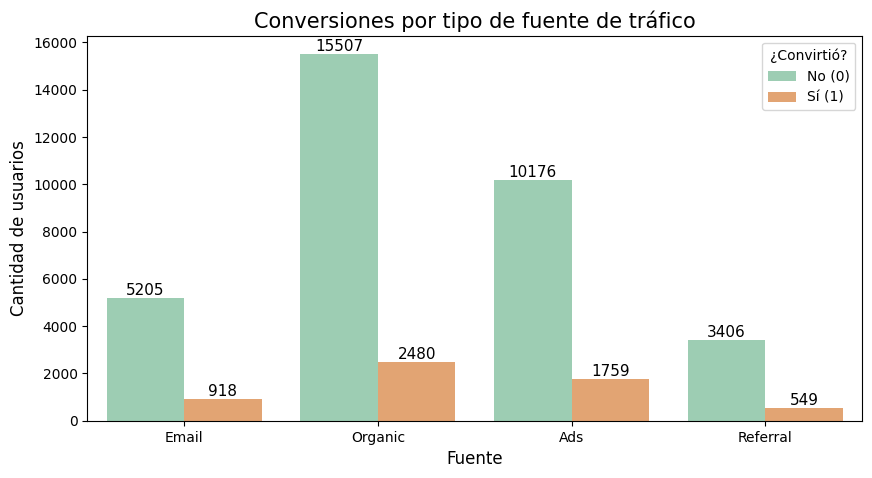

In [42]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=data, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por tipo de fuente de tráfico', fontsize=15)
plt.xlabel('Fuente', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: El gráfico muestra la distribución de usuarios convertidos y no convertidos según su canal de origen. En términos de volumen, Organic domina ampliamente con 15,507 usuarios que no convirtieron y 2,480 que sí lo hicieron, seguido por Ads (10,176 y 1,759 respectivamente). Los canales Email y Referral concentran menor tráfico, con 5,205 y 3,406 usuarios no convertidos, y 918 y 549 conversiones cada uno.
En todos los canales se observa el mismo patrón: la mayoría de los usuarios no completa una conversión, lo cual es consistente con la tasa de conversión general del experimento (~14%). Esto refuerza visualmente los resultados de la prueba chi-cuadrado: aunque existe una asociación estadísticamente significativa entre el canal y la conversión, las diferencias en la proporción de usuarios convertidos entre fuentes son pequeñas y su impacto práctico es limitado.

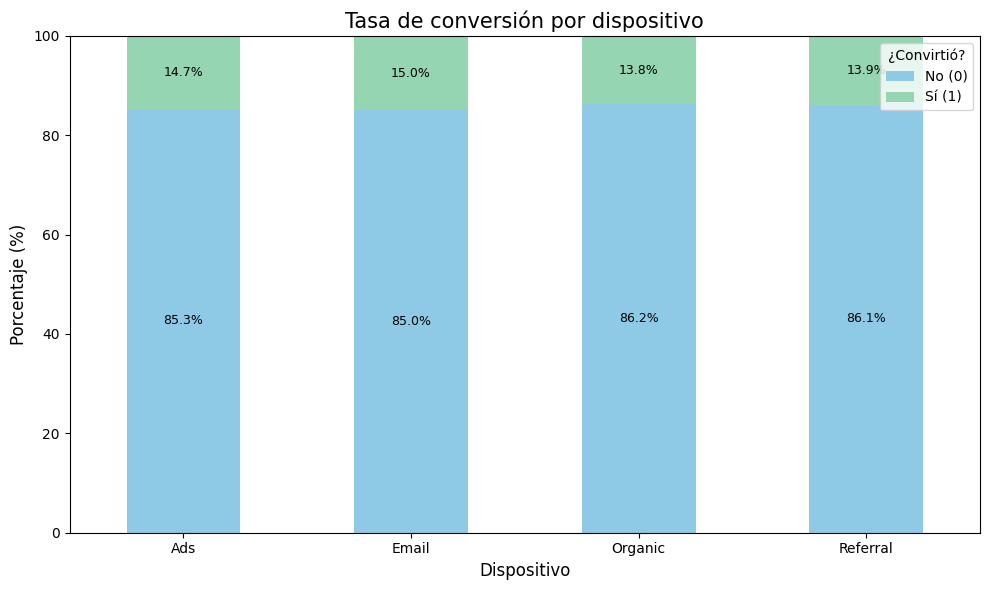

In [34]:
# Gráfica de barras apiladas
ax = tabla_contingencia.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de conversión por dispositivo', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
for i, row in enumerate(tabla_contingencia.values):
    acumulado = 0
    for j, valor in enumerate(row):
        ax.text(
            i, 
            acumulado + valor / 2, 
            f"{valor:.1f}%", 
            ha='center', 
            va='center',
            fontsize=9
        )
        acumulado += valor
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

✍️ **Comentario**: El gráfico de barras apiladas muestra la proporción de usuarios convertidos y no convertidos por canal de tráfico, permitiendo comparar la efectividad relativa de cada fuente independientemente de su volumen.
A diferencia del gráfico anterior, aquí se observa que las tasas de conversión entre canales son muy similares entre sí: Email lidera con 15.0%, seguido de Ads con 14.7%, Referral con 13.9% y Organic con 13.8%. La brecha entre el canal con mayor y menor tasa de conversión es de apenas 1.2 puntos porcentuales.
Esta visualización complementa y refuerza el resultado de la prueba chi-cuadrado: aunque la asociación entre canal y conversión es estadísticamente significativa, la similitud en las proporciones entre fuentes sugiere que ningún canal presenta una ventaja práctica relevante sobre los demás en términos de efectividad de conversión.

### Relación entre el tipo de usuario y la conversión

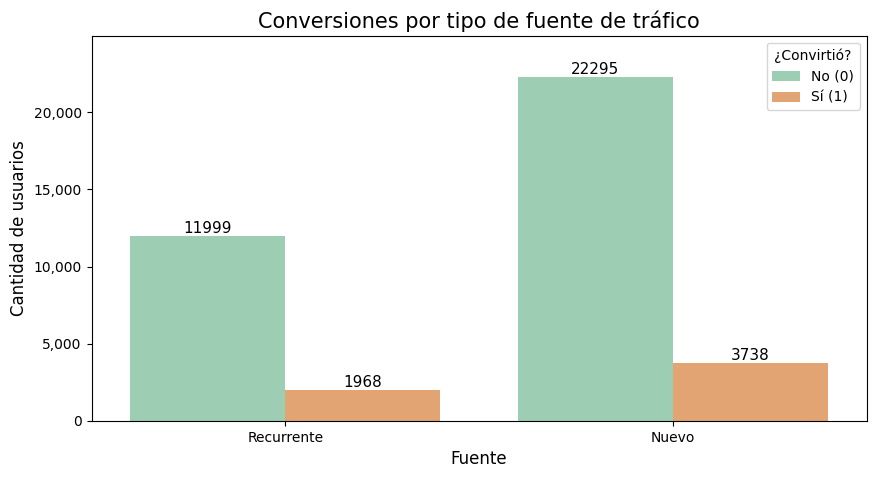

In [41]:

import matplotlib.ticker as mticker

# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=data, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Escala automática con margen superior para las etiquetas
max_val = max([bar.get_height() for bar in ax.patches])
ax.set_ylim(0, max_val * 1.12)  # 12% de margen arriba

# Formatear eje Y con separador de miles
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Añadir detalles
plt.title('Conversiones por tipo de fuente de tráfico', fontsize=15)
plt.xlabel('Fuente', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()




✍️ **Comentario**: El gráfico muestra la distribución de usuarios convertidos y no convertidos según su tipo: nuevo o recurrente. En volumen, los usuarios nuevos son el grupo dominante con 22,295 no convertidos y 3,738 conversiones, mientras que los recurrentes registran 11,999 no convertidos y 1,968 conversiones, lo que refleja la composición del dataset donde los usuarios nuevos representan aproximadamente el 65% del total.
En ambos grupos se mantiene el mismo patrón: la gran mayoría de usuarios no completa una conversión, lo cual es consistente con el resultado de la prueba chi-cuadrado (χ² = 0.513, p = 0.474), que no encontró evidencia suficiente de asociación entre el tipo de usuario y la conversión. El comportamiento ante la landing page fue similar independientemente del historial previo del usuario.


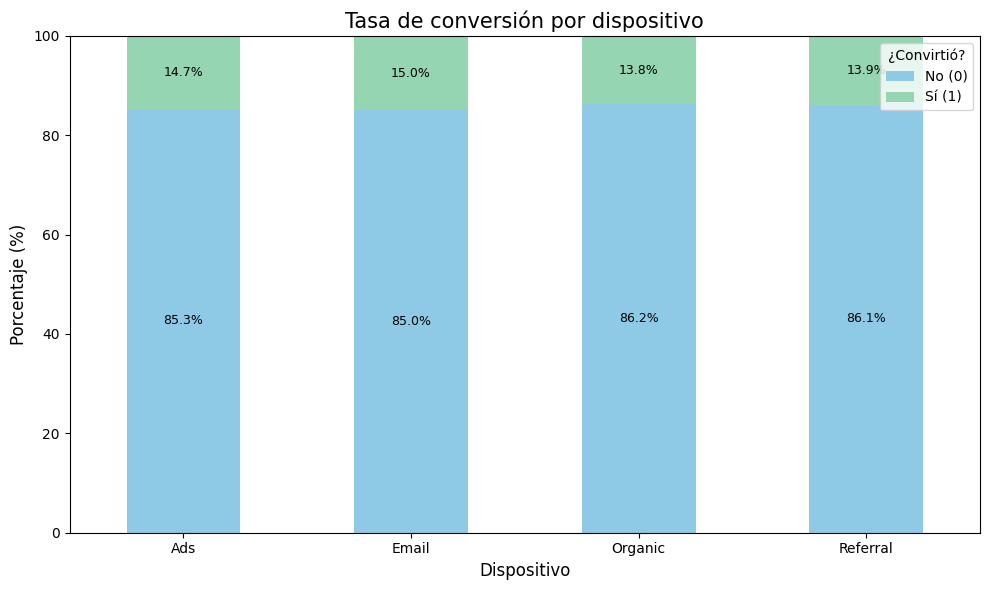

In [39]:
ax = tabla_contingencia.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de conversión por dispositivo', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
for i, row in enumerate(tabla_contingencia.values):
    acumulado = 0
    for j, valor in enumerate(row):
        ax.text(
            i, 
            acumulado + valor / 2, 
            f"{valor:.1f}%", 
            ha='center', 
            va='center',
            fontsize=9
        )
        acumulado += valor
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

✍️ **Comentario**: El gráfico de barras apiladas muestra la proporción de usuarios convertidos y no convertidos por tipo de usuario, complementando el análisis de volumen del gráfico anterior. Al normalizar los datos, se hace evidente que las tasas de conversión entre usuarios nuevos y recurrentes son prácticamente idénticas: 14.36% para nuevos y 14.09% para recurrentes, con una diferencia de apenas 0.27 puntos porcentuales.
Esta visualización refuerza directamente el resultado de la prueba chi-cuadrado (χ² = 0.513, p = 0.474): la proporción de conversiones es tan similar entre ambos grupos que no es posible distinguir visualmente una ventaja de un perfil sobre el otro. El historial previo del usuario no parece estar relacionado con su probabilidad de convertir en el contexto de este experimento.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

# 🌟 Insight Ejecutivo basado en el Experimento A/B

---

## 🔍 Comparación de página (A vs B)

### Gasto promedio por usuario que convirtió

| Métrica | Página A | Página B |
|---|---|---|
| Gasto promedio | $61.09 USD | $68.75 USD |
| Usuarios convertidos | 2,512 | 3,194 |
| Diferencia | — | +$7.65 USD |

- Los usuarios que convirtieron en la página B gastaron en promedio $68.75 USD,
  mientras que los de la página A gastaron $61.09 USD, una diferencia de
  **$7.65 USD** a favor de B.
- La prueba de Levene confirmó varianzas desiguales entre ambos grupos, por lo que
  se aplicó una **prueba T**, la cual arrojó un valor p extremadamente
  pequeño (`p = 3.63e-21`), muy por debajo del umbral de significancia de 0.05.

> **Interpretación:** Los datos muestran evidencia estadística de que, entre los
> usuarios que convirtieron, quienes vieron la página B tendieron a gastar más en
> promedio. Esta diferencia es estadísticamente significativa, aunque el análisis
> se limita a usuarios que ya realizaron una compra y no permite concluir que la
> página B *cause* directamente un mayor gasto. El resultado sugiere que B podría
> estar asociada a un mayor valor por cliente adquirido, lo que merece considerarse
> en la decisión de negocio.

---

### Tasa de conversión

| Métrica | Página A | Página B |
|---|---|---|
| Usuarios totales | 19,982 | 20,018 |
| Conversiones | 2,512 | 3,194 |
| Tasa de conversión | 12.57% | 15.96% |
| Diferencia | — | +3.38 pp |

- La página A obtuvo una tasa de conversión del **12.57%**, mientras que la
  página B alcanzó el **15.96%**, una diferencia de **3.38 puntos porcentuales**.
- La **prueba Z para proporciones** confirmó que esta diferencia es estadísticamente
  significativa (`p = 3.76e-22`), lo que hace muy poco probable que sea producto
  del azar bajo las condiciones del experimento.

> **Interpretación:** Los resultados sugieren que la página B estuvo asociada a una
> mayor proporción de usuarios que completaron una conversión durante el período del
> experimento. Si bien la significancia estadística es sólida, la magnitud de la
> diferencia (3.38 pp) debe evaluarse en el contexto del negocio para determinar si
> justifica un cambio definitivo, considerando factores como el costo de
> implementación y posibles efectos de novedad.

---

## 📊 Segmentación por fuente de tráfico

| Canal | Tasa de conversión |
|---|---|
| Email | 14.99% |
| Ads | 14.74% |
| Referral | 13.88% |
| Organic | 13.79% |

- La **prueba chi-cuadrado** encontró una asociación estadísticamente significativa
  entre la fuente de tráfico y la conversión (`χ² = 8.662`, `p = 0.034`).

> **Interpretación:** Aunque existe evidencia de asociación entre el canal de origen
> y la conversión, las diferencias observadas son pequeñas (brecha máxima de
> ~1.2 pp), por lo que su impacto práctico podría ser limitado. Este análisis es
> observacional y no permite establecer causalidad; otros factores no controlados
> podrían estar influyendo en las tasas por canal. Se recomienda considerar estos
> resultados como una señal exploratoria que podría guiar pruebas más específicas
> por canal.

---

## 📊 Segmentación por tipo de usuario

| Tipo de usuario | Tasa de conversión |
|---|---|
| Nuevo | 14.36% |
| Recurrente | 14.09% |

- No se encontró asociación estadísticamente significativa entre el tipo de usuario
  y la conversión (`χ² = 0.513`, `p = 0.474`).

> **Interpretación:** Con base en los datos disponibles, no hay evidencia suficiente
> para afirmar que el tipo de usuario esté relacionado con la probabilidad de
> conversión en este experimento. Esto sugiere que la respuesta a la landing page
> fue consistente entre ambos perfiles, aunque no descarta que diferencias podrían
> emerger en contextos distintos de segmentación.

---

> 📈 Las visualizaciones de barras agrupadas y barras apiladas utilizadas en el
> análisis respaldan visualmente los resultados estadísticos de cada paso,
> confirmando de forma consistente las tendencias observadas entre versiones,
> canales y perfiles de usuario.

---

## 💡 Recomendaciones de negocio

1. **Considerar la página B como candidata para implementación.**
   La evidencia estadística indica que B estuvo asociada a una mayor tasa de
   conversión y un mayor gasto promedio por usuario convertido. Sin embargo, se
   recomienda evaluar también el costo de implementación y monitorear si los
   resultados se mantienen fuera del contexto controlado del experimento antes de
   tomar una decisión definitiva.

2. **Explorar estrategias para el canal Organic.**
   Al concentrar el 45% del tráfico total, optimizar su tasa de conversión (la más baja entre los canales) tendría el mayor impacto potencial en volumen de clientes.

3. **Mantener la inversión en Email y Ads con seguimiento.**
   Estos canales mostraron las tasas de conversión más altas dentro del experimento.
   Aunque la diferencia con otros canales es modesta, sostener y monitorear su
   rendimiento puede ayudar a confirmar si esta ventaja es consistente en el tiempo.

4. **No priorizar segmentación por tipo de usuario en esta etapa.**
   Dado que no se encontró diferencia significativa en la conversión entre usuarios
   nuevos y recurrentes, no hay evidencia en estos datos que justifique personalizar
   la landing page según este criterio por ahora.